In [1]:
# These modules are required for the data reduction.
from dysh.log import init_logging
from dysh.fits.gbtfitsload import GBTFITSLoad
from astropy import units as u

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="nod2")

16:05:44.215 I Resolving example=nod2 -> nod-KFPA/data/TGBT22A_503_02.raw.vegas.trim.fits


16:05:44.216 I url: http://www.gb.nrao.edu/dysh//example_data/nod-KFPA/data/TGBT22A_503_02.raw.vegas.trim.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/nod-KFPA/data/TGBT22A_503_02.raw.vegas.trim.fits
TGBT22A_503_02.raw.vegas.trim.fits already downloaded


In [4]:
sdfits = GBTFITSLoad(filename)

In [5]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
60,W3_1,-40.0,OnOff,1,23.694496,1,1,31,1,324.2279,38.7060
61,W3_1,-40.0,OnOff,2,23.694496,1,1,31,1,324.1526,39.0121
62,W3_1,-40.0,Nod,1,23.694496,1,1,31,7,324.2743,38.4194
63,W3_1,-40.0,Nod,2,23.694496,1,1,31,7,324.3672,38.2858


In [6]:
nodsb = sdfits.getnod(scan=62, ifnum=0, plnum=0)
nodsb

16:05:44.908 I Ignoring 1 blanked integration(s).


16:05:45.289 I Ignoring 1 blanked integration(s).


ScanBlock([NodScan scan=62 ifnum=0 (rest freq=23.69 GHz) plnum=0 (LL) fdnum=2 source='W3_1',
           NodScan scan=62 ifnum=0 (rest freq=23.69 GHz) plnum=0 (LL) fdnum=6 source='W3_1'])

In [7]:
nodsb[0].tsys, nodsb[1].tsys

(array([64.0651583 , 65.84723928, 63.32246857, 64.9772735 , 63.77161495,
        62.82267302, 66.41525105, 62.88090753, 60.91140946, 62.18854417,
        60.81960096, 61.42624138, 59.32883166, 60.16711155, 61.45232073,
        60.71780304, 59.21079399, 62.45297224, 62.54435652, 64.53549963,
        65.65949202, 64.34252275, 64.24356553, 65.4308054 , 65.54581989,
        64.64741319, 62.45646939, 62.62895287, 61.91170188, 63.05362163]),
 array([73.42457338, 73.89318167, 77.95484204, 77.06676577, 79.64183646,
        80.67187842, 75.41180075, 74.18340271, 79.06335209, 82.58279698,
        78.22566126, 70.88384081, 68.7912057 , 69.28174137, 72.48114802,
        72.24762512, 74.46373175, 73.26477026, 73.02711593, 70.51565007,
        72.7222005 , 71.37948284, 71.11466717, 70.09686344, 70.74295942,
        69.47116087, 70.22771754, 67.13519555, 70.62961633, 69.03334933]))

In [8]:
nodsb[0].exposure, nodsb[1].exposure

(array([0.97587454, 0.97236673, 0.97587454, 0.97095654, 0.97587454,
        0.97587454, 0.97060335, 0.97587454, 0.97060334, 0.97587454,
        0.97587454, 0.97587454, 0.97060334, 0.97587454, 0.97060334,
        0.97587454, 0.97587454, 0.97095652, 0.97587454, 0.97095652,
        0.97587454, 0.97587454, 0.97060334, 0.97587454, 0.97060335,
        0.97587454, 0.97587454, 0.97060335, 0.97587454, 0.97587454]),
 array([0.97587454, 0.97201457, 0.97587454, 0.97095654, 0.97587454,
        0.97587454, 0.97095654, 0.97587454, 0.97060334, 0.97587454,
        0.97587454, 0.97587454, 0.97095654, 0.97587454, 0.97060334,
        0.97587454, 0.97587454, 0.97060334, 0.97587454, 0.97095652,
        0.97587454, 0.97587454, 0.97095654, 0.97587454, 0.97095654,
        0.97587454, 0.97587454, 0.97095654, 0.97587454, 0.97587454]))

In [9]:
nodsb[0].fdnum, nodsb[1].fdnum

(2, 6)

In [10]:
nod_int = nodsb[0].getspec(0)
nod_int

<Spectrum(flux=[nan ... 1.7525686101720952] K (shape=(32768,), mean=3.35429 K); spectral_axis=<SpectralAxis 
   (observer: <ITRS Coordinate (obstime=2022-02-17T03:12:46.500, location=(0.0, 0.0, 0.0) km): (x, y, z) in m
                  (882593.9465029, -4924896.36541728, 3943748.74743984)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (36.37731467, 62.10479638, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (-3.65939096e-22, 0., -40.)>
    observer to target (computed from above):
      radial_velocity=-18.322117140068272 km / s
      redshift=-6.111413679055211e-05
    doppler_rest=23694495500.0 Hz
    doppler_convention=radio)
  [2.36845708e+10 2.36845715e+10 2.36845722e+10 ... 2.37080061e+10
 2.37080069e+10 2.37080076e+10] Hz> (length=32768))>

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


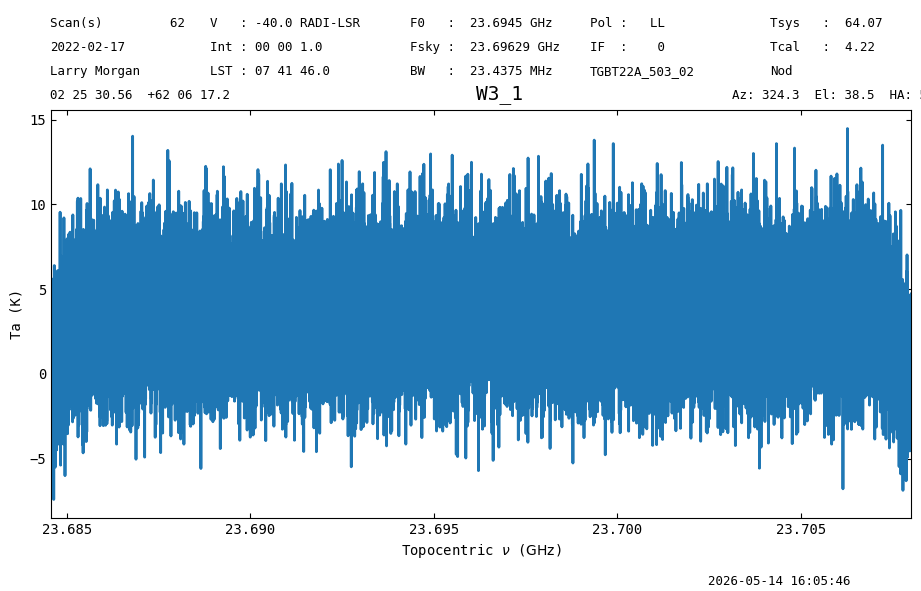

In [11]:
nod_int.plot()

In [12]:
nod_ta = nodsb.timeaverage()
nod_ta

<Spectrum(flux=[-0.16442172102764782 ... -0.10698105320590705] K (shape=(32768,), mean=0.37476 K); spectral_axis=<SpectralAxis 
   (observer: <ITRS Coordinate (obstime=2022-02-17T03:12:46.500, location=(0.0, 0.0, 0.0) km): (x, y, z) in m
                  (882593.9465029, -4924896.36541728, 3943748.74743984)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (36.38569729, 62.08575673, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (-7.31878192e-22, 7.31878192e-22, -40.)>
    observer to target (computed from above):
      radial_velocity=-18.31506656233015 km / s
      redshift=-6.109062003167853e-05
    doppler_rest=23694495500.0 Hz
    doppler_convention=radio)
  [2.36845708e+10 2.36845715e+10 2.36845722e+10 ... 2.37080061e+10
 2.37080069e+10 2.37080076e+10] Hz> (length=32768))>

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


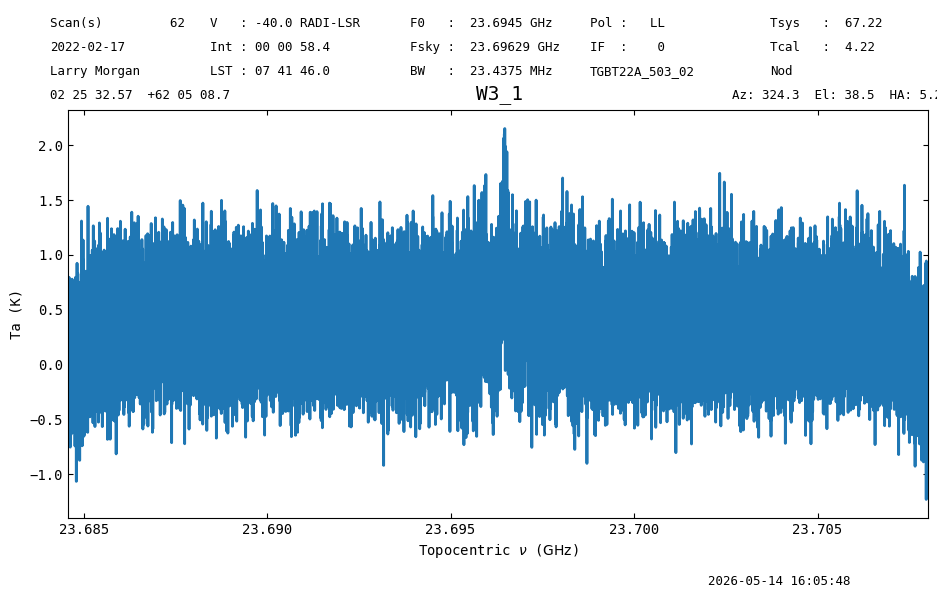

In [13]:
nod_ta.plot()

In [14]:
nod_ta_smooth = nod_ta.smooth('box', 51)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


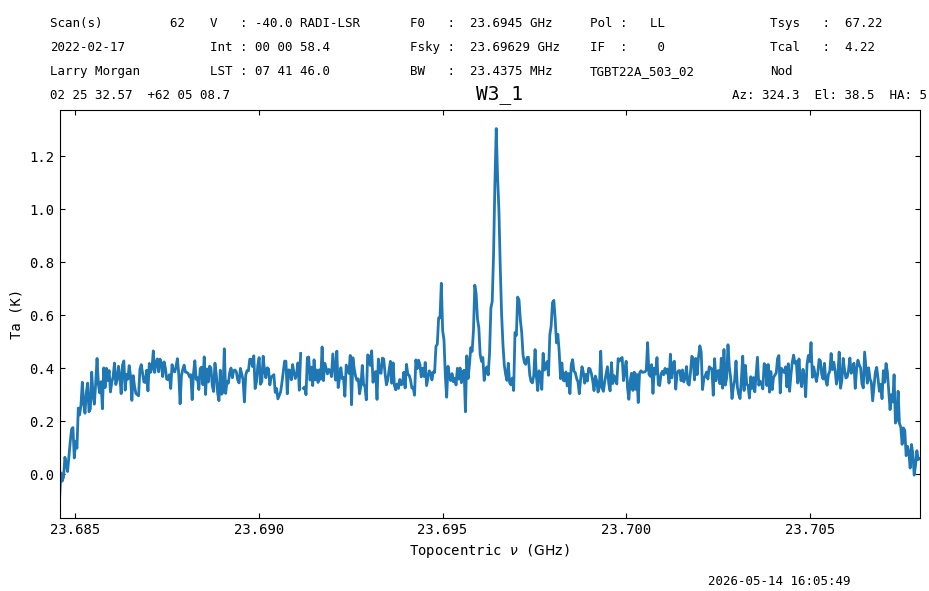

In [15]:
nod_ta_smooth.plot(xaxis_unit="GHz")

In [16]:
s = slice(23.687*u.GHz, 23.694*u.GHz)

In [17]:
nod_ta_smooth[s].stats()  # rms 0.04587208 K

16:05:50.853 I Note: found 1 NaN (masked) values


{'mean': <Quantity 0.37603136 K>,
 'median': <Quantity 0.38060805 K>,
 'rms': <Quantity 0.04587208 K>,
 'min': <Quantity 0.26205572 K>,
 'max': <Quantity 0.48034968 K>,
 'npt': 191,
 'nan': np.int64(1)}

In [18]:
nod_ta[s].stats() # rms 0.33878936 K

16:05:51.688 I Note: found 52 NaN (masked) values


{'mean': <Quantity 0.3758673 K>,
 'median': <Quantity 0.36945952 K>,
 'rms': <Quantity 0.33836405 K>,
 'min': <Quantity -0.92130551 K>,
 'max': <Quantity 1.58757768 K>,
 'npt': 9787,
 'nan': np.int64(52)}

In [19]:
include = [(23.687*u.GHz, 23.694*u.GHz),
           (23.700*u.GHz, 23.705*u.GHz)
          ]
model = "poly"
order = 1

nod_ta_smooth.baseline(order, model=model, include=include, remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


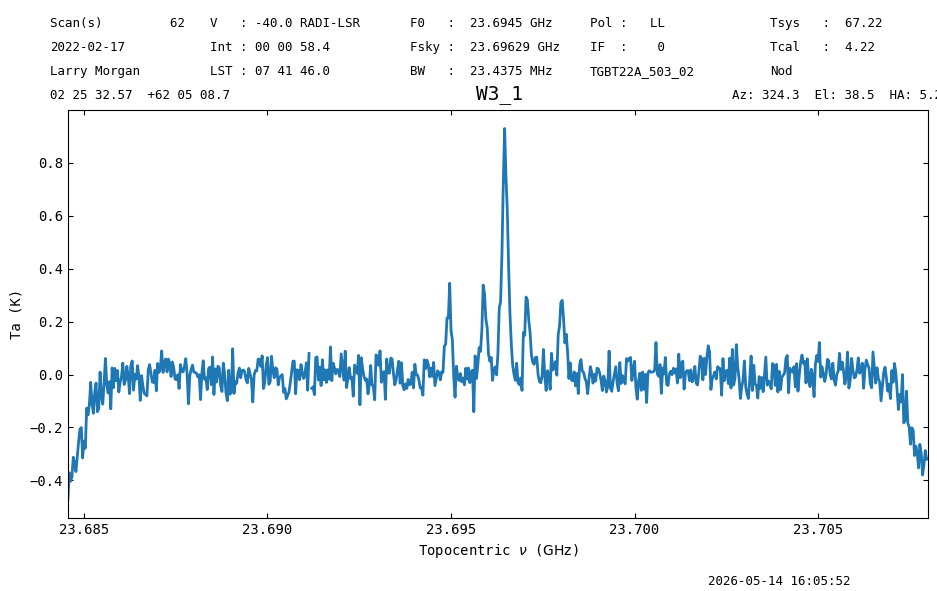

In [20]:
nod_ta_smooth.plot()

In [21]:
pssb = sdfits.getps(scan=60, plnum=0, ifnum=0, fdnum=0)
pssb

16:05:52.738 I Ignoring 1 blanked integration(s).


ScanBlock([PSScan scan=60 ifnum=0 (rest freq=23.69 GHz) plnum=0 (LL) fdnum=0 source='W3_1'])

In [22]:
ps_ta_smooth = pssb.timeaverage().smooth("box", 51)
ps_ta_smooth.baseline(order, model=model, include=include, remove=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


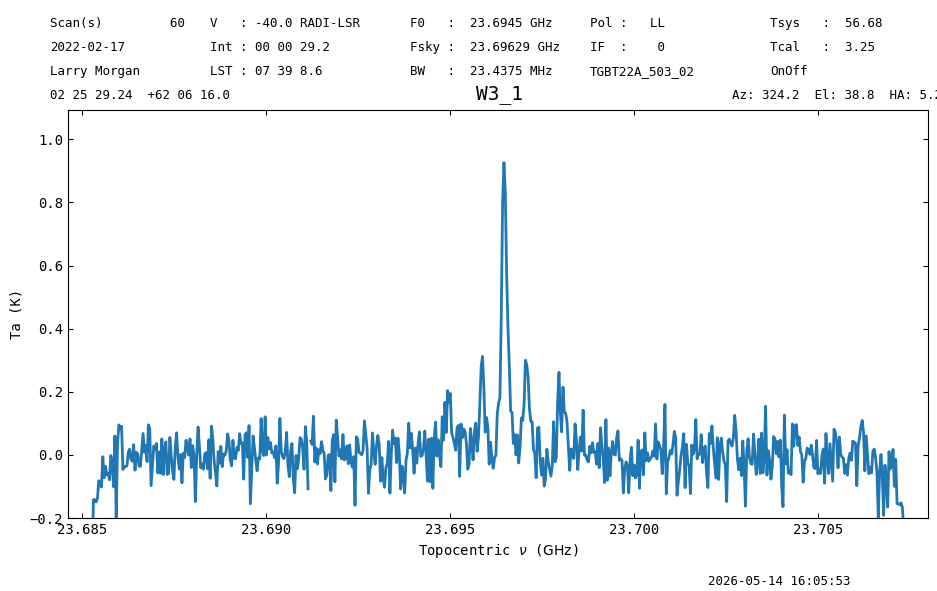

In [23]:
ps_ta_smooth.plot(ymin=-0.2)

In [24]:
# Line free rms
nod_ta_smooth[s].stats()["rms"], ps_ta_smooth[s].stats()["rms"]

16:05:54.650 I Note: found 1 NaN (masked) values


16:05:55.491 I Note: found 1 NaN (masked) values


(<Quantity 0.04586959 K>, <Quantity 0.0557227 K>)

In [25]:
ps_ta_smooth[s].stats()["rms"]/nod_ta_smooth[s].stats()["rms"]/2**0.5

16:05:56.339 I Note: found 1 NaN (masked) values


16:05:57.130 I Note: found 1 NaN (masked) values


<Quantity 0.85899819>

In [26]:
ps_ta_smooth.meta["TSYS"]/nod_ta_smooth.meta["TSYS"]

np.float64(0.8432606926356401)

In [27]:
# Line peak
nod_ta_smooth.stats()["max"], ps_ta_smooth.stats()["max"]

16:05:57.159 I Note: found 1 NaN (masked) values


16:05:57.163 I Note: found 2 NaN (masked) values


(<Quantity 0.92860103 K>, <Quantity 0.9264315 K>)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


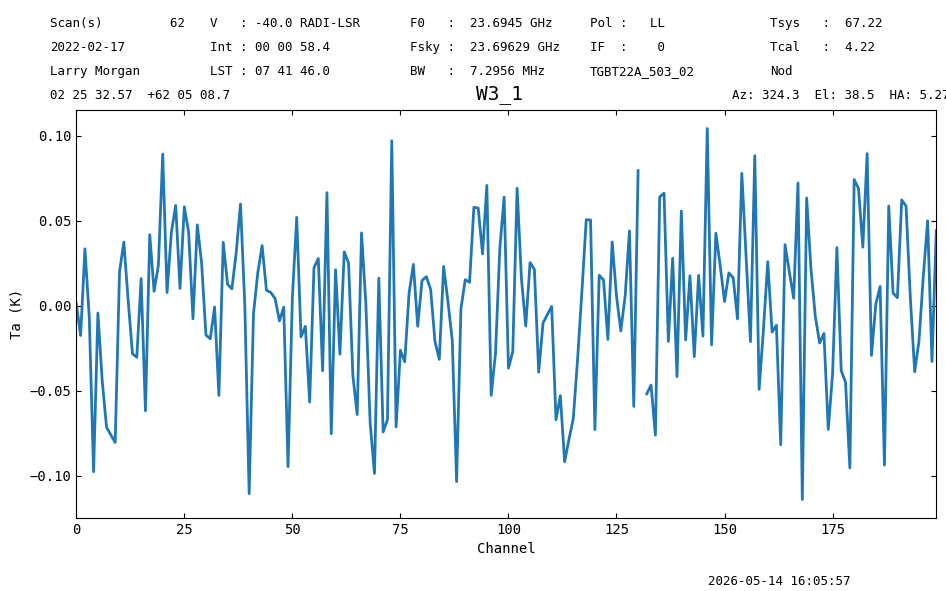

16:05:57.634 I Note: found 1 NaN (masked) values


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


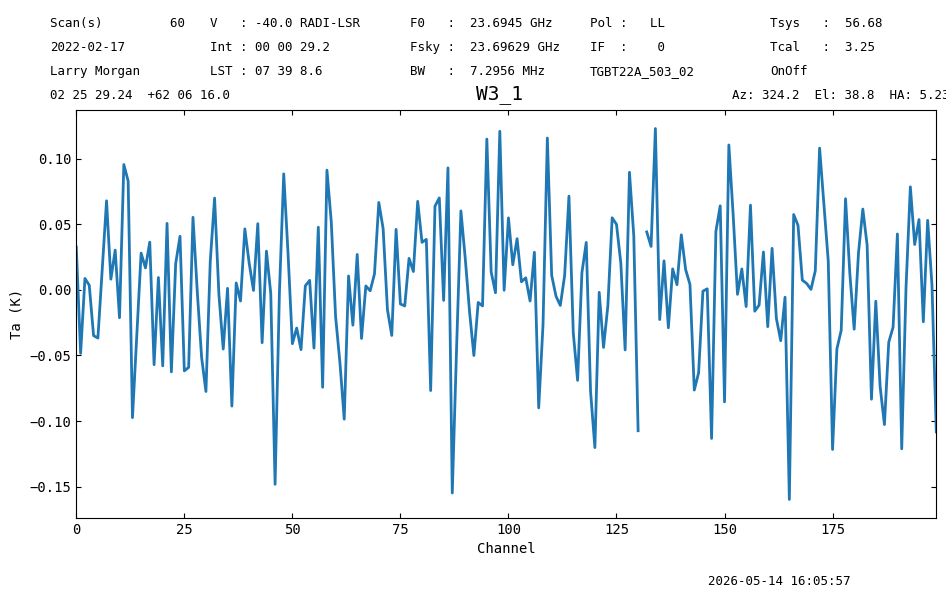

16:05:58.112 I Note: found 1 NaN (masked) values


(np.float64(1.004327561874331), np.float64(0.9949180273182222))

In [28]:
# radiometer in a non-signal part of the spectrum:    (1.0043275608304512, 0.994918029194119) 
nod_ta_smooth[50:250].plot(xaxis_unit="chan").spectrum.radiometer(), ps_ta_smooth[50:250].plot(xaxis_unit="chan").spectrum.radiometer(),

In [29]:
nod_ta_smooth.check_stats(0.11354235 * u.K)

16:05:58.130 I Note: found 1 NaN (masked) values


16:05:58.131 I rms is OK 
